# Figure 9 — Cross-species comparison: raw performance, and behavioral strategy independent of performance level

**NEW figure for the reviewer response — not part of the original manuscript, no legend to match against.**

This figure is now explicitly two parts, following a direct discussion with
the user about what a fair cross-species comparison actually requires:

**Part 1 — raw, classifier-independent performance (80-20 only).** P(chose
the higher-value option) and raw single-trial switch rate, mouse vs.
marmoset, at the one condition both species' task design shares most
directly. No `Behavioral_State` involved at all. This answers "do mice and
marmosets perform differently at the same task parameters" on its own
terms, so it can't be confounded by any classifier/threshold choice made
below.

**Part 2 — behavioral strategy, independent of performance level (panels
a-d, across each species' own condition gradient).**

- **a** — behavioral state proportions vs. reward probability of the better option
- **b** — sticky Q-learning + choice-kernel model parameters (alpha/beta/kappa)
- **c** — win-stay / lose-switch by behavioral state
- **d** — raw single-trial switch rate by behavioral state

**Why Part 1 exists at all, and why Part 2's classifier changed (2026-09-18):**
Part 1's own numbers (see that section) confirmed mice really do have
higher accuracy and lower switch rates than marmosets at the shared 80-20/
90-10 conditions -- a real, classifier-independent effect, not a threshold
artifact. That means an absolute state-classifier boundary calibrated on
ONE species and applied to both (which is what this figure originally did
-- marmoset's own `classify_state_updated_noAdapting` thresholds, applied
to mouse data unchanged) conflates "different baseline performance level"
with "different strategy": mice would mechanically show more
"Exploitation" simply because their raw accuracy sits further above any
fixed bar, not necessarily because they use a different exploit/explore
strategy. Part 2 therefore classifies EACH species against its OWN
K-means-derived thresholds (`marmoset` for marmoset, `mouse_calibrated`
for mouse -- see `derive_mouse_thresholds.py`), asking "is this
Exploitation-like FOR THIS SPECIES" rather than "does this clear one fixed
bar" -- a fairer strategy comparison, at the cost of the two species no
longer sharing one absolute scale.

Panel b (model params) is unaffected by any of this -- the sticky-model
fit doesn't use `Behavioral_State` at all, and is numerically identical
under every threshold set (verified directly).

**Known, disclosed limitation (panels c/d only):** under `mouse_calibrated`
thresholds, mouse Exploitation's win-stay/lose-switch and switch-rate are
EXACTLY 1.0/0.0/0.0 -- verified directly against the trial data (0 of
247,325 Exploitation-labeled trials have `PhysicalSwitch==1`). This is not
a real behavioral finding; it's a tautological consequence of
`directed_switch_floor` (0.16, set because mouse Exploitation's own
K-means centroid switch-rate is ~0.008) sitting below the smallest
achievable nonzero `Rolling_Switch_Rate`, combined with `Rolling_Accuracy`
and `Rolling_Switch_Rate` being computed from the same trailing window (so
a same-trial switch almost always drags accuracy below
`directed_acc_ceiling` too, routing that trial to Directed Exploration
instead of Exploitation). Panels c/d exclude mouse Exploitation
specifically rather than plot a misleading exact 0/1 -- see
`config.yaml`'s `fig9.panels_cd_excluded_states` and `fig9.py`'s panel c/d
docstrings.

`Unknown` (NaN-feature rolling-window edge artifacts) is excluded from
every classifier-based panel -- not a real behavioral state.

Marmoset and mouse only share two conditions (80-20, 90-10); each species
also has one condition the other doesn't (marmoset's deterministic 100-0,
mouse's harder 70-30). Rather than force-align mismatched condition sets,
both are plotted on the same shared continuous x-axis -- reward
probability of the better option -- so the genuine overlap lines up
directly and each species' own extension is still visible.

Data: `cross_species_comparison/run_pipeline.py --thresholds marmoset` and
`--thresholds mouse_calibrated` (mouse side, both already existing) and
`cross_species_comparison/run_pipeline_marmoset.py --thresholds marmoset`
(marmoset side, built for this figure -- see that script's own docstring
for why it's a separate, condition-generic script rather than reusing
`state_features.py`, which hardcodes the 80-20 condition's specific
probability values).

In [1]:
import os
import sys
import json

import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import SVG, display

sys.path.insert(0, os.path.abspath(".."))

from src.io.load_snapshots import load_config
from src.plotting.style import apply_style
from src.plotting import fig9 as plotting

config = load_config()
apply_style(config)
cfg = config["fig9"]

CROSS_SPECIES_DIR = os.path.normpath(os.path.join(os.path.abspath(".."), cfg["cross_species_dir"]))
# Marmoset and mouse now read from DIFFERENT threshold-set directories --
# see this notebook's intro cell for why (species-calibrated classifiers,
# not one species' thresholds applied to both).
MARMOSET_THRESH_DIR = os.path.join(CROSS_SPECIES_DIR, "outputs", f"{cfg['marmoset_threshold_set']}_thresholds")
MOUSE_THRESH_DIR = os.path.join(CROSS_SPECIES_DIR, "outputs", f"{cfg['mouse_threshold_set']}_thresholds")
print(f"Reading marmoset outputs from: {MARMOSET_THRESH_DIR}")
print(f"Reading mouse outputs from:    {MOUSE_THRESH_DIR}")

FIG_DIR = os.path.join("..", config["paths"]["figures_out"], "Fig9")
os.makedirs(FIG_DIR, exist_ok=True)
MANIFEST_DIR = os.path.join("..", config["paths"]["values_manifests_out"])
os.makedirs(MANIFEST_DIR, exist_ok=True)

manifest = {"_stage": "Fig 9 -- cross-species comparison (marmoset vs. mouse), NEW figure for the reviewer response"}


def show(path):
    display(SVG(path))


def load(name):
    """Mouse-side files have no species prefix; marmoset-side files are
    prefixed marmoset_ (see run_pipeline_marmoset.py's own README note on
    why -- avoids colliding with the pre-existing unprefixed mouse files
    in the same outputs/<threshold_set>_thresholds/ directory). Each
    species is read from its OWN threshold-set directory now."""
    mouse = pd.read_csv(os.path.join(MOUSE_THRESH_DIR, f"{name}.csv"))
    marmoset = pd.read_csv(os.path.join(MARMOSET_THRESH_DIR, f"marmoset_{name}.csv"))
    return marmoset, mouse

# Per-animal marmoset palette (config.yaml's plotting.animal_colors/animal_order --
# same one used throughout Fig1-Fig5 and fig8_3cond.py). Mice have no
# established per-individual color convention, so per-animal breakdowns
# below are marmoset-only.
ANIMAL_COLORS = config["plotting"]["animal_colors"]
ANIMAL_ORDER = config["plotting"]["animal_order"]

# Panels a/b already have a per-animal CSV precomputed by
# run_pipeline_marmoset.py. Panels c/d don't -- derived here directly from
# the raw classified trial data, mirroring that script's own aggregate
# switch-rate/win-stay-lose-switch cells exactly, just with an added
# per-animal split (see run_pipeline_marmoset.py's own cells for the
# un-split version this matches).
sys.path.insert(0, CROSS_SPECIES_DIR)
from run_pipeline import compute_win_stay_lose_switch  # noqa: E402

marmoset_classified = pd.read_csv(os.path.join(MARMOSET_THRESH_DIR, "marmoset_df_classified.csv"), low_memory=False)
marmoset_classified = marmoset_classified[marmoset_classified["Behavioral_State"] != "Unknown"]

# Raw per-trial data for Part 1 (accuracy/switch-rate are classifier-
# independent columns already on this file -- Behavioral_State itself
# isn't used for Part 1 at all, only High_Prob/PhysicalSwitch).
mouse_classified_raw = pd.read_csv(os.path.join(MOUSE_THRESH_DIR, "df_classified.csv"), low_memory=False)

marmoset_switch_by_animal = (
    marmoset_classified.groupby(["prob_Condition", "Behavioral_State", "Animal_Name"])["PhysicalSwitch"]
    .agg(["mean", "count"]).rename(columns={"mean": "switch_rate", "count": "n_trials"})
    .reset_index().rename(columns={"prob_Condition": "Condition"})
)

# compute_win_stay_lose_switch only needs Mouse/Session renamed (same
# rename run_pipeline_marmoset.py itself uses, and the same reason it
# doesn't also rename prob_Condition -> Condition: the raw data already
# has its own unrelated Condition column).
df_for_wsls = marmoset_classified.rename(columns={"Animal_Name": "Mouse", "Session_ID": "Session"})
wsls_rows = []
for (cond, animal), adf in df_for_wsls.groupby(["prob_Condition", "Mouse"]):
    for state, sdf in adf.groupby("Behavioral_State"):
        if len(sdf) < 10:
            continue
        ws, ls, n_win, n_lose = compute_win_stay_lose_switch(sdf, adf)
        wsls_rows.append({
            "Condition": cond, "Animal_Name": animal, "Behavioral_State": state,
            "win_stay": ws, "lose_switch": ls,
            "n_win_trials": n_win, "n_lose_trials": n_lose, "n_trials": len(sdf),
        })
marmoset_wsls_by_animal = pd.DataFrame(wsls_rows)

print(f"Per-animal switch-rate rows: {len(marmoset_switch_by_animal)}; "
      f"per-animal win-stay/lose-switch rows: {len(marmoset_wsls_by_animal)}")

Reading marmoset outputs from: /Users/kevinmastro/Documents/Github/marmoset_decision_making/cross_species_comparison/outputs/marmoset_thresholds
Reading mouse outputs from:    /Users/kevinmastro/Documents/Github/marmoset_decision_making/cross_species_comparison/outputs/mouse_calibrated_thresholds
Per-animal switch-rate rows: 94; per-animal win-stay/lose-switch rows: 91


## Part 1 — raw performance, 80-20 only

Classifier-independent: `High_Prob` (chose the higher-value option) and
`PhysicalSwitch`, per subject, at `cfg["performance_condition"]` (80-20 --
the condition both species' task design shares most directly). This is
computed BEFORE any Behavioral_State classification, so it can't be
affected by the threshold-set discussion in Part 2 below.

Raw performance at 80-20 (per-subject, then mean +/- SEM across subjects):
  marmoset: accuracy=0.688+/-0.002  switch_rate=0.197+/-0.016  n_subjects=5
  mouse: accuracy=0.828+/-0.005  switch_rate=0.066+/-0.008  n_subjects=6

Unpaired t-test (different species, different subjects, different n):
  accuracy:    t=-22.834  p=2.814e-09
  switch_rate: t=7.723  p=2.931e-05


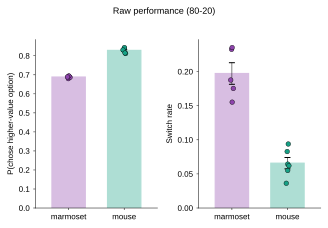

In [2]:
PERF_COND = cfg["performance_condition"]

def per_subject_performance(df, cond_col, id_col, condition):
    d = df[df[cond_col] == condition]
    return d.groupby(id_col).agg(
        accuracy=("High_Prob", "mean"),
        switch_rate=("PhysicalSwitch", "mean"),
        n_trials=("High_Prob", "size"),
    ).reset_index()

marmoset_perf = per_subject_performance(marmoset_classified, "prob_Condition", "Animal_Name", PERF_COND)
mouse_perf = per_subject_performance(mouse_classified_raw, "Condition", "Mouse", PERF_COND)

print(f"Raw performance at {PERF_COND} (per-subject, then mean +/- SEM across subjects):")
for label, perf in [("marmoset", marmoset_perf), ("mouse", mouse_perf)]:
    print(f"  {label}: accuracy={perf['accuracy'].mean():.3f}+/-{perf['accuracy'].sem():.3f}  "
          f"switch_rate={perf['switch_rate'].mean():.3f}+/-{perf['switch_rate'].sem():.3f}  "
          f"n_subjects={len(perf)}")

t_acc, p_acc = stats.ttest_ind(marmoset_perf["accuracy"], mouse_perf["accuracy"])
t_sw, p_sw = stats.ttest_ind(marmoset_perf["switch_rate"], mouse_perf["switch_rate"])
print(f"\nUnpaired t-test (different species, different subjects, different n):")
print(f"  accuracy:    t={t_acc:.3f}  p={p_acc:.4g}")
print(f"  switch_rate: t={t_sw:.3f}  p={p_sw:.4g}")

manifest["part1_performance_condition"] = PERF_COND
manifest["part1_marmoset_perf"] = marmoset_perf.to_dict(orient="records")
manifest["part1_mouse_perf"] = mouse_perf.to_dict(orient="records")
manifest["part1_accuracy_ttest"] = {"t": float(t_acc), "p": float(p_acc)}
manifest["part1_switch_rate_ttest"] = {"t": float(t_sw), "p": float(p_sw)}

out_perf = os.path.join(FIG_DIR, "Fig9_perf_80-20.svg")
plotting.plot_panel_performance_80_20(marmoset_perf, mouse_perf, cfg, out_perf)
show(out_perf)

## Part 2 — strategy, independent of performance level\n\n### Panel a — state proportions

Excludes `Unknown`; states in a fixed order (`config.yaml`'s `fig9.states_order`) so panels are comparable across the figure.

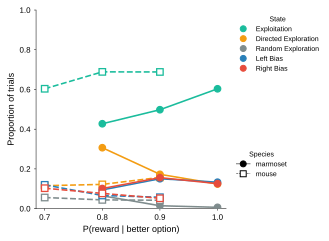

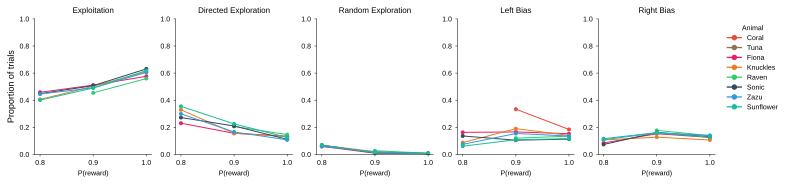

In [3]:
marmoset_prop, mouse_prop = load("state_proportions_by_condition")
marmoset_prop = marmoset_prop[marmoset_prop["Behavioral_State"] != "Unknown"]
mouse_prop = mouse_prop[mouse_prop["Behavioral_State"] != "Unknown"]

manifest["panel_a_marmoset_state_proportions"] = marmoset_prop.to_dict(orient="records")
manifest["panel_a_mouse_state_proportions"] = mouse_prop.to_dict(orient="records")

out_a = os.path.join(FIG_DIR, "Fig9a_state_proportions.svg")
plotting.plot_panel_a_state_proportions(marmoset_prop, mouse_prop, cfg, out_a)
show(out_a)

marmoset_prop_by_animal = pd.read_csv(os.path.join(MARMOSET_THRESH_DIR, "marmoset_state_proportions_by_condition_and_animal.csv"))
marmoset_prop_by_animal = marmoset_prop_by_animal[marmoset_prop_by_animal["Behavioral_State"] != "Unknown"]
manifest["panel_a_marmoset_state_proportions_by_animal"] = marmoset_prop_by_animal.to_dict(orient="records")

out_a_animal = os.path.join(FIG_DIR, "Fig9a_marmoset_by_animal.svg")
plotting.plot_marmoset_per_animal_by_state(
    marmoset_prop_by_animal, cfg["states_order"], cfg["marmoset_conditions_order"], cfg["condition_to_prob"],
    "proportion", "Proportion of trials", ANIMAL_COLORS, ANIMAL_ORDER, out_a_animal, ylim=(0, 1.0),
)
show(out_a_animal)

## Panel b — sticky Q-learning + choice-kernel model parameters

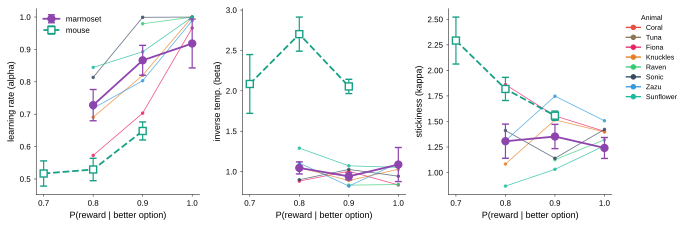

In [4]:
# Column names differ (Animal_Name vs. Mouse) but both scripts own
# per-subject fit tables are otherwise the same shape.
marmoset_fits = pd.read_csv(os.path.join(MARMOSET_THRESH_DIR, "marmoset_sticky_model_params_by_animal_by_condition.csv"))
mouse_fits = pd.read_csv(os.path.join(MOUSE_THRESH_DIR, "sticky_model_params_by_mouse_by_condition.csv"))

def _flat_param_summary(fits):
    s = fits.groupby("Condition")[["alpha", "beta", "kappa"]].agg(["mean", "sem"])
    s.columns = [f"{param}_{stat}" for param, stat in s.columns]
    return s.reset_index().to_dict(orient="records")

manifest["panel_b_marmoset_param_summary"] = _flat_param_summary(marmoset_fits)
manifest["panel_b_mouse_param_summary"] = _flat_param_summary(mouse_fits)

out_b = os.path.join(FIG_DIR, "Fig9b_model_params.svg")
plotting.plot_panel_b_model_params(
    marmoset_fits, mouse_fits, cfg, out_b,
    marmoset_fits_by_animal=marmoset_fits, animal_colors=ANIMAL_COLORS, animal_order=ANIMAL_ORDER,
)
show(out_b)

## Panel c — win-stay / lose-switch by state

Watch marmoset's Exploitation lose-switch column: it stays low (~0.10-0.16) at the probabilistic conditions (80-20, 90-10) but jumps to ~0.95 at its deterministic 100-0 -- consistent with a loss being a 100%-reliable "you picked wrong" signal only when reward is deterministic, unlike the probabilistic conditions where a single loss is often just noise.

**Mouse Exploitation is intentionally absent from this panel** -- see this notebook's intro cell and `fig9.py`'s own `plot_panel_c_winstay_loseswitch` docstring for why (its win-stay/lose-switch is exactly 1.0/0.0 under `mouse_calibrated` thresholds, a tautology of the classifier boundary, not a real finding).

Exploitation lose-switch by condition:
  marmoset: Condition  lose_switch
    100-0     0.947005
    80-20     0.101545
    90-10     0.157474
  mouse:    Condition  lose_switch
    70-30          0.0
    80-20          0.0
    90-10          0.0


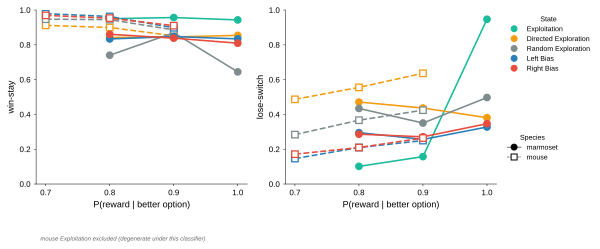

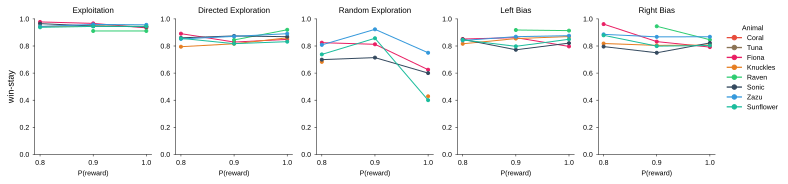

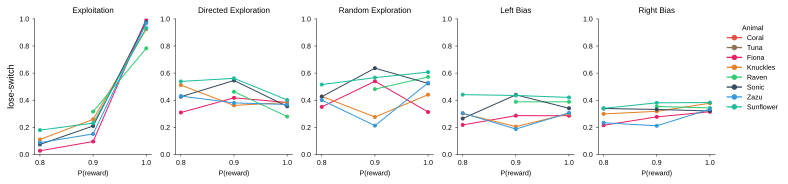

In [5]:
marmoset_wsls, mouse_wsls = load("winstay_loseswitch_by_state_by_condition")
marmoset_wsls = marmoset_wsls[marmoset_wsls["Behavioral_State"] != "Unknown"]
mouse_wsls = mouse_wsls[mouse_wsls["Behavioral_State"] != "Unknown"]

manifest["panel_c_marmoset_winstay_loseswitch"] = marmoset_wsls.to_dict(orient="records")
manifest["panel_c_mouse_winstay_loseswitch"] = mouse_wsls.to_dict(orient="records")

print("Exploitation lose-switch by condition:")
print("  marmoset:", marmoset_wsls[marmoset_wsls['Behavioral_State']=='Exploitation'][['Condition','lose_switch']].to_string(index=False))
print("  mouse:   ", mouse_wsls[mouse_wsls['Behavioral_State']=='Exploitation'][['Condition','lose_switch']].to_string(index=False))

out_c = os.path.join(FIG_DIR, "Fig9c_winstay_loseswitch.svg")
plotting.plot_panel_c_winstay_loseswitch(marmoset_wsls, mouse_wsls, cfg, out_c)
show(out_c)

manifest["panel_c_marmoset_winstay_loseswitch_by_animal"] = marmoset_wsls_by_animal.to_dict(orient="records")

out_c_ws_animal = os.path.join(FIG_DIR, "Fig9c_marmoset_by_animal_winstay.svg")
plotting.plot_marmoset_per_animal_by_state(
    marmoset_wsls_by_animal, cfg["states_order"], cfg["marmoset_conditions_order"], cfg["condition_to_prob"],
    "win_stay", "win-stay", ANIMAL_COLORS, ANIMAL_ORDER, out_c_ws_animal, ylim=(0, 1.0),
)
show(out_c_ws_animal)

out_c_ls_animal = os.path.join(FIG_DIR, "Fig9c_marmoset_by_animal_loseswitch.svg")
plotting.plot_marmoset_per_animal_by_state(
    marmoset_wsls_by_animal, cfg["states_order"], cfg["marmoset_conditions_order"], cfg["condition_to_prob"],
    "lose_switch", "lose-switch", ANIMAL_COLORS, ANIMAL_ORDER, out_c_ls_animal, ylim=(0, 1.0),
)
show(out_c_ls_animal)

## Panel d — switch rate by state

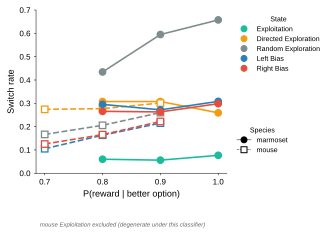

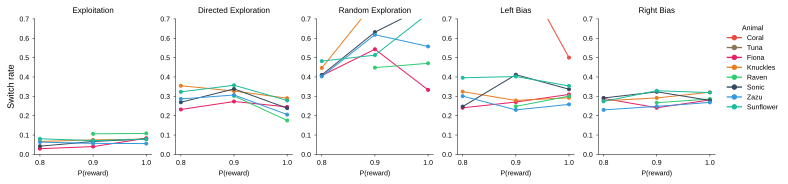

In [6]:
marmoset_switch, mouse_switch = load("switch_rate_by_state_by_condition")
marmoset_switch = marmoset_switch[marmoset_switch["Behavioral_State"] != "Unknown"]
mouse_switch = mouse_switch[mouse_switch["Behavioral_State"] != "Unknown"]

manifest["panel_d_marmoset_switch_rate"] = marmoset_switch.to_dict(orient="records")
manifest["panel_d_mouse_switch_rate"] = mouse_switch.to_dict(orient="records")

out_d = os.path.join(FIG_DIR, "Fig9d_switch_rate.svg")
plotting.plot_panel_d_switch_rate(marmoset_switch, mouse_switch, cfg, out_d)
show(out_d)

manifest["panel_d_marmoset_switch_rate_by_animal"] = marmoset_switch_by_animal.to_dict(orient="records")

out_d_animal = os.path.join(FIG_DIR, "Fig9d_marmoset_by_animal.svg")
plotting.plot_marmoset_per_animal_by_state(
    marmoset_switch_by_animal, cfg["states_order"], cfg["marmoset_conditions_order"], cfg["condition_to_prob"],
    "switch_rate", "Switch rate", ANIMAL_COLORS, ANIMAL_ORDER, out_d_animal, ylim=(0, 0.7),
)
show(out_d_animal)

## Values manifest

In [7]:
manifest_path = os.path.join(MANIFEST_DIR, "Fig9.json")
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"Saved values manifest: {manifest_path}")

Saved values manifest: ../outputs/values_manifests/Fig9.json
